# Geographic İnformation System - Coğrafi Bilgi Sistemi

<img src = 'https://gisgeography.com/wp-content/uploads/2014/07/What-Is-Geographic-Information-Systems-Featured-1265x727.jpg'> 

In [10]:
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot,plot
init_notebook_mode(connected=True)

C:\Users\USER\anaconda3\Lib\site-packages\kaleido\__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('2014_World_Power_Consumption')

In [13]:
df.head()

,Country,Power Consumption KWH,Text
0,China,5.523000e+12,"China 5,523,000,000,000"
1,United States,3.832000e+12,"United 3,832,000,000,000"
2,European,2.771000e+12,"European 2,771,000,000,000"
3,Russia,1.065000e+12,"Russia 1,065,000,000,000"
4,Japan,9.210000e+11,"Japan 921,000,000,000"


In [14]:
data=dict(
    type="choropleth",
    colorscale='Viridis',
    reversescale=True,
    locations=df["Country"],
    locationmode="country names",
    z=df["Power Consumption KWH"],
    text=df["Country"],
    colorbar={'title':"World Power Consunmption"}
)
layout=dict(title="World Power Consunmption",
            geo=dict(showframe=False,projection={'type':'mercator'})
            )


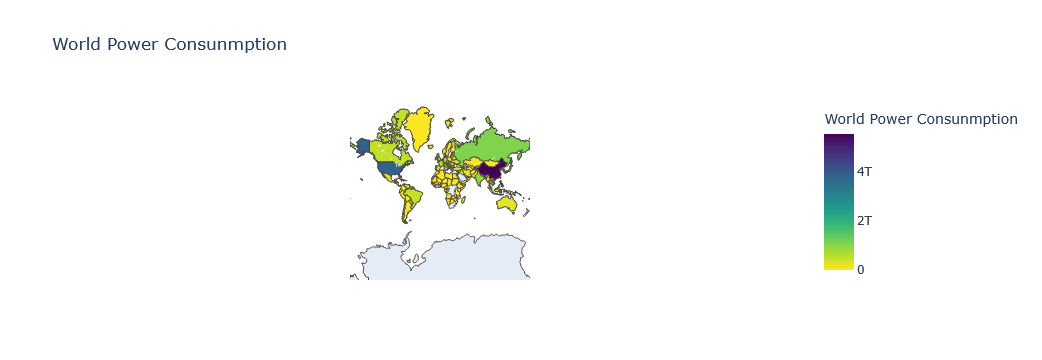

In [15]:
choromap=go.Figure(data=data,layout=layout)
iplot(choromap,validate=False)

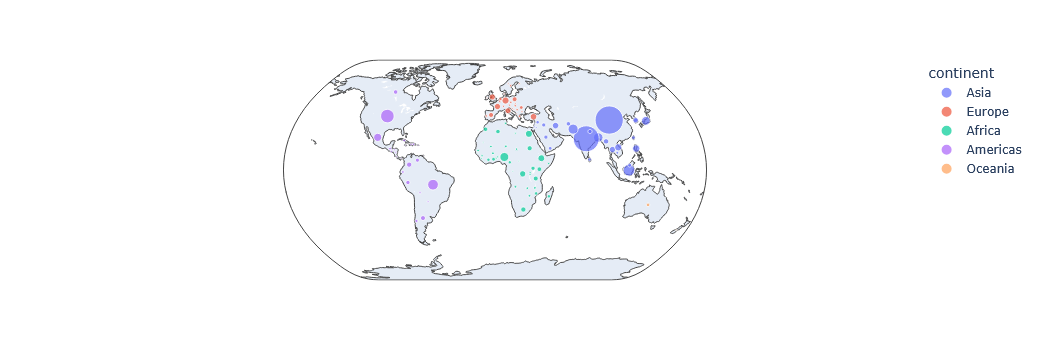

In [16]:
import plotly.express as px
df = px.data.gapminder().query("year==2007")
fig = px.scatter_geo(df, locations="iso_alpha", color="continent",
                     hover_name="country", size="pop",
                     projection="natural earth")
fig.show()

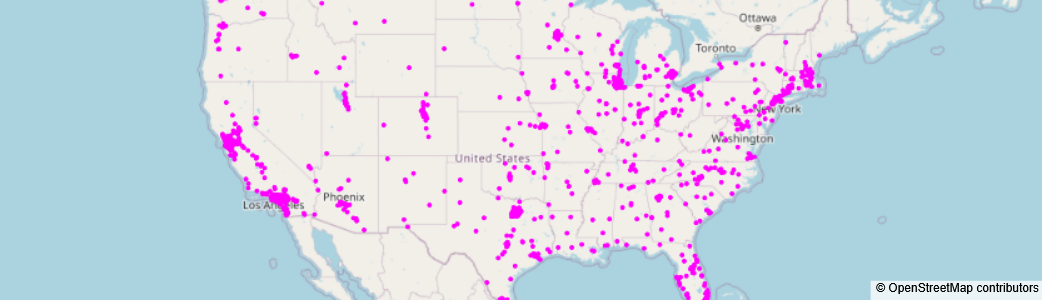

In [17]:
import pandas as pd
us_cities = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv")

import plotly.express as px

fig = px.scatter_mapbox(us_cities, lat="lat", lon="lon", hover_name="City", hover_data=["State", "Population"],
                        color_discrete_sequence=["fuchsia"], zoom=3, height=300)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

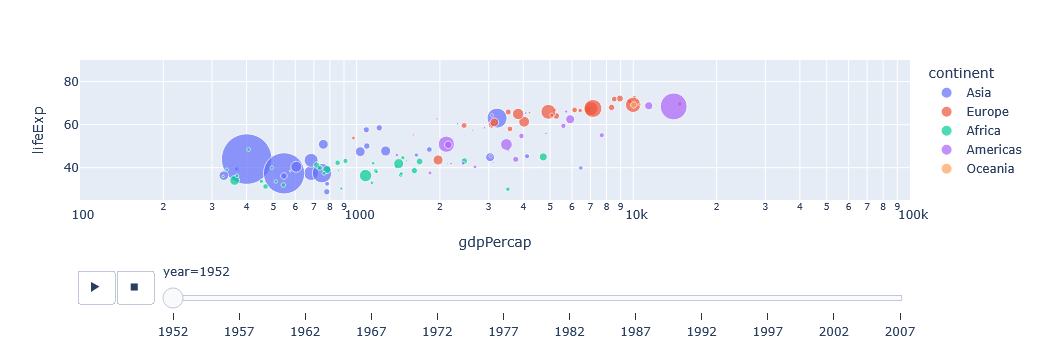

In [18]:
import plotly.express as px
df = px.data.gapminder()
px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
           size="pop", color="continent", hover_name="country",
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

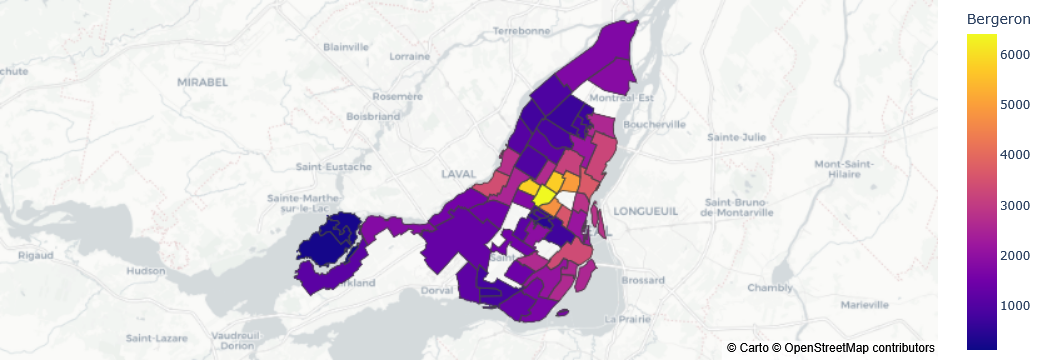

In [19]:
import plotly.express as px

df = px.data.election()
geojson = px.data.election_geojson()

fig = px.choropleth_mapbox(df, geojson=geojson, color="Bergeron",
                           locations="district", featureidkey="properties.district",
                           center={"lat": 45.5517, "lon": -73.7073},
                           mapbox_style="carto-positron", zoom=9)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [23]:
#pip install leafmap

In [22]:
import leafmap.foliumap as leafmap

In [24]:
m = leafmap.Map()
m.add_basemap("USGS 3DEP Elevation")
colors = ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
vmin = 0
vmax = 4000
m.add_colorbar(colors=colors, vmin=vmin, vmax=vmax)
m

In [25]:
url = "https://opengeos.org/data/landsat/peru.zip"
leafmap.download_file(url)

Downloading...
From: https://opengeos.org/data/landsat/peru.zip
To: C:\Users\USER\Desktop\Artificial_Intelligence_Course\day10\peru.zip
100%|█████████████████████████████████████████████████████████████████████████████| 33.8M/33.8M [00:00<00:00, 39.8MB/s]

Extracting files...


'C:\\Users\\USER\\Desktop\\Artificial_Intelligence_Course\\day10\\peru.zip'

In [26]:
images = "peru/*.tif"

In [27]:
m = leafmap.Map()
images = "landsat"
m.add_time_slider(
    images,
    time_interval=0.5,
    position="bottomright",
    band=[1, 2, 3],
    zoom_to_layer=True,
)
m

NotImplementedError: The folium plotting backend does not support this function. Use the ipyleaflet plotting backend instead.

In [28]:
m = leafmap.Map()
m.add_basemap("HYBRID")
m

In [29]:
m.to_html("mymap.html")